In [1]:
from google.colab import drive
import os
import shutil

mount_point = '/content/drive'

# Attempt to unmount if already mounted
if os.path.ismount(mount_point):
  try:
    drive.flush_and_unmount()
    print(f'Google Drive unmounted successfully from {mount_point}.')
  except Exception as e:
    print(f'Error during unmount: {e}. This might be normal if it was partially mounted or not fully connected.')

# Ensure the mount point directory is truly clean before attempting to mount
if os.path.exists(mount_point):
  # If it exists, remove it and its contents to ensure it's empty for drive.mount
  print(f"Cleaning up existing {mount_point} directory before mount.")
  try:
    shutil.rmtree(mount_point)
  except OSError as e:
    print(f"Error removing {mount_point} during cleanup: {e}. Attempting to create an empty directory anyway.")

# Recreate an empty directory for the mount point
os.makedirs(mount_point, exist_ok=True)
print(f"Created/Ensured empty directory: {mount_point}")

# Mount Google Drive
drive.mount(mount_point)

Created/Ensured empty directory: /content/drive
Mounted at /content/drive


In [2]:
# Cell 1 - Imports
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import tensorflow.data as tfd
import json, datetime
print(f"TF: {tf.__version__}")

TF: 2.20.0


In [9]:
# Cell 13 - PREDICTION (updated custom_objects)

import json, numpy as np, tensorflow as tf, editdistance
from tensorflow import keras
from tensorflow.keras import layers

# Load vocabulary
with open('/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/vocabulary.json', 'r', encoding='utf-8') as f:
    vocabulary = json.load(f)
char_to_num = layers.StringLookup(vocabulary=vocabulary, mask_token=None)
num_to_char = layers.StringLookup(vocabulary=vocabulary, mask_token=None, invert=True)
print(f"Vocabulary loaded: {len(vocabulary)} tokens")


# Custom layers
class ChannelMeanPool(layers.Layer):
    def call(self, x):
        return tf.reduce_mean(x, axis=-1, keepdims=True)
    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (1,)

class ChannelMaxPool(layers.Layer):
    def call(self, x):
        return tf.reduce_max(x, axis=-1, keepdims=True)
    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (1,)

class MainCTCLayer(layers.Layer):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.loss_fn = keras.backend.ctc_batch_cost
    def call(self, inputs):
        y_true, y_pred = inputs
        bl = tf.cast(tf.shape(y_true)[0], dtype='int64')
        il = tf.cast(tf.shape(y_pred)[1], dtype='int64') * tf.ones((bl,1), dtype='int64')
        ll = tf.cast(tf.shape(y_true)[1], dtype='int64') * tf.ones((bl,1), dtype='int64')
        self.add_loss(self.loss_fn(y_true, y_pred, il, ll))
        return y_pred
    def get_config(self): return super().get_config()

class PathCTCLayer(layers.Layer):
    def __init__(self, path_name, initial_weight=0.1, min_weight=0.02,
                 decay_epochs=15, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.path_name=path_name; self.initial_weight=initial_weight
        self.min_weight=min_weight; self.decay_epochs=decay_epochs
        self.loss_fn=keras.backend.ctc_batch_cost
        self.epoch=tf.Variable(0.0, trainable=False)
    def call(self, inputs):
        y_true, y_pred = inputs
        bl = tf.cast(tf.shape(y_true)[0], dtype='int64')
        il = tf.cast(tf.shape(y_pred)[1], dtype='int64') * tf.ones((bl,1), dtype='int64')
        ll = tf.cast(tf.shape(y_true)[1], dtype='int64') * tf.ones((bl,1), dtype='int64')
        loss = self.loss_fn(y_true, y_pred, il, ll)
        ne   = tf.minimum(self.epoch / self.decay_epochs, 1.0)
        w    = self.min_weight + (self.initial_weight - self.min_weight) * ((1.0 - ne)**2)
        self.add_loss(w * loss)
        return y_pred
    def get_config(self):
        c = super().get_config()
        c.update({'path_name': self.path_name, 'initial_weight': self.initial_weight,
                  'min_weight': self.min_weight, 'decay_epochs': self.decay_epochs})
        return c


# Load inference model
keras.config.enable_unsafe_deserialization()
model = keras.models.load_model(
    '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/inference_model.keras',
    custom_objects={
        'MainCTCLayer':   MainCTCLayer,
        'PathCTCLayer':   PathCTCLayer,
        'ChannelMeanPool': ChannelMeanPool,   # ← NEW
        'ChannelMaxPool':  ChannelMaxPool,    # ← NEW
    },
    safe_mode=False
)
print(f"Model loaded: {model.input_shape} -> {model.output_shape}")

Vocabulary loaded: 75 tokens
Model loaded: (None, 200, 50, 3) -> (None, 300, 76)


In [10]:
# Cell 14 - Predict Function
def predict_image(image_path, model):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.resize(img, (50, 200))        # HEIGHT=50, WIDTH=200
    img = tf.transpose(img, perm=[1, 0, 2])      # Same as training!
    img = tf.expand_dims(img, axis=0)
    pred = model.predict(img, verbose=0)
    il   = np.ones(pred.shape[0]) * pred.shape[1]
    res  = keras.backend.ctc_decode(pred, input_length=il, greedy=True)[0][0].numpy()
    text = ''
    for idx in res[0]:
        if idx != -1:
            text += num_to_char(tf.constant([idx])).numpy()[0].decode('utf-8')
    return text

# Test
test_path  = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/maI16_00_1-7.jpg'   # UPDATE THIS
true_label = 'നാമാസ'           # UPDATE THIS

pred = predict_image(test_path, model)
cer  = editdistance.eval(pred, true_label) / len(true_label) * 100
print(f"True:      {true_label}")
print(f"Predicted: {pred}")
print(f"CER:       {cer:.2f}%")

True:      നാമാസ
Predicted: ന്ാമാസ
CER:       20.00%


In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

def show_character_locations(image_path, model,
                              num_to_char, img_w=200, img_h=50):

    # Load and preprocess image
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.resize(img, (img_h, img_w))
    img = tf.transpose(img, perm=[1, 0, 2])
    img_input = tf.expand_dims(img, axis=0)

    # Get raw probability matrix (300 × 76)
    pred = model.predict(img_input, verbose=0)
    prob_matrix = pred[0]  # (300, 76)

    # FIX: CTC decode correctly
    il = np.ones(pred.shape[0]) * pred.shape[1]
    decoded_raw = keras.backend.ctc_decode(
        pred, input_length=il, greedy=True
    )[0][0].numpy()   # shape: (300,) or (1, max_len)

    # FIX: flatten and filter
    decoded_flat = decoded_raw.flatten()

    predicted_chars = []
    for idx in decoded_flat:
        if idx != -1:
            ch = num_to_char(tf.constant([int(idx)]))
            predicted_chars.append(
                (int(idx), ch.numpy()[0].decode('utf-8'))
            )

    pred_text = ''.join([c for _, c in predicted_chars])
    print(f"Predicted text: {pred_text}")

    # ── Find approximate location of each character ───────────
    blank_idx      = prob_matrix.shape[1] - 1
    non_blank_prob = prob_matrix[:, :blank_idx]
    blank_prob     = prob_matrix[:, blank_idx]

    is_char    = blank_prob < 0.5
    char_at_t  = np.argmax(non_blank_prob, axis=1)
    t_to_pixel = img_w / prob_matrix.shape[0]

    # Find character regions
    char_regions  = []
    current_char  = None
    x_start       = 0

    for t in range(prob_matrix.shape[0]):
        if is_char[t]:
            char_idx = int(char_at_t[t])
            if char_idx != current_char:
                if current_char is not None:
                    x_end = int(t * t_to_pixel)
                    ch    = num_to_char(
                        tf.constant([current_char])
                    ).numpy()[0].decode('utf-8')
                    char_regions.append((ch, x_start, x_end))
                current_char = char_idx
                x_start      = int(t * t_to_pixel)
        else:
            if current_char is not None:
                x_end = int(t * t_to_pixel)
                ch    = num_to_char(
                    tf.constant([current_char])
                ).numpy()[0].decode('utf-8')
                char_regions.append((ch, x_start, x_end))
                current_char = None

    # Handle last character
    if current_char is not None:
        ch = num_to_char(
            tf.constant([current_char])
        ).numpy()[0].decode('utf-8')
        char_regions.append((ch, x_start, img_w))

    print(f"\nCharacter locations (approximate):")
    for ch, x1, x2 in char_regions:
        print(f"  '{ch}' → pixels {x1} to {x2}")

    # ── Visualize ──────────────────────────────────────────────
    orig = cv2.imread(image_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    oh, ow = orig.shape[:2]
    scale  = ow / img_w

    colors = [
        (255,0,0),(0,200,0),(0,0,255),(255,165,0),
        (128,0,128),(0,200,200),(255,20,147),
        (139,69,19),(0,180,0),(70,130,180),
    ]

    annotated = orig.copy()
    for i, (ch, x1, x2) in enumerate(char_regions):
        sx1 = int(x1 * scale)
        sx2 = int(x2 * scale)
        col = colors[i % len(colors)]
        cv2.rectangle(annotated, (sx1,0), (sx2,oh), col, 2)
        cv2.putText(annotated, ch, (sx1+2, 20),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, col, 2)

    # ── Plot ───────────────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(20, 10))

    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title(
        f'Approximate Locations: {pred_text}',
        fontsize=12
    )
    axes[1].axis('off')

    axes[2].imshow(
        prob_matrix[:, :blank_idx].T,
        aspect='auto', cmap='hot'
    )
    axes[2].set_xlabel('Timestep (0 to 300)')
    axes[2].set_ylabel('Character index')
    axes[2].set_title(
        'CTC Probability Heatmap\n'
        'Bright = high probability at that timestep'
    )

    plt.tight_layout()
    plt.show()

    return char_regions, prob_matrix

Predicted text: ന്ാമാസ

Character locations (approximate):
  'ന' → pixels 8 to 8
  '്' → pixels 18 to 18
  'ാ' → pixels 59 to 60
  'മ' → pixels 87 to 88
  'ാ' → pixels 122 to 123
  'സ' → pixels 150 to 151


/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3368 (\N{MALAYALAM LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3405 (\N{MALAYALAM SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3390 (\N{MALAYALAM VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3374 (\N{MALAYALAM LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3384 (\N{MALAYALAM LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3368 (\N{MALAYALAM LETTER NA}) missing from font(s) 

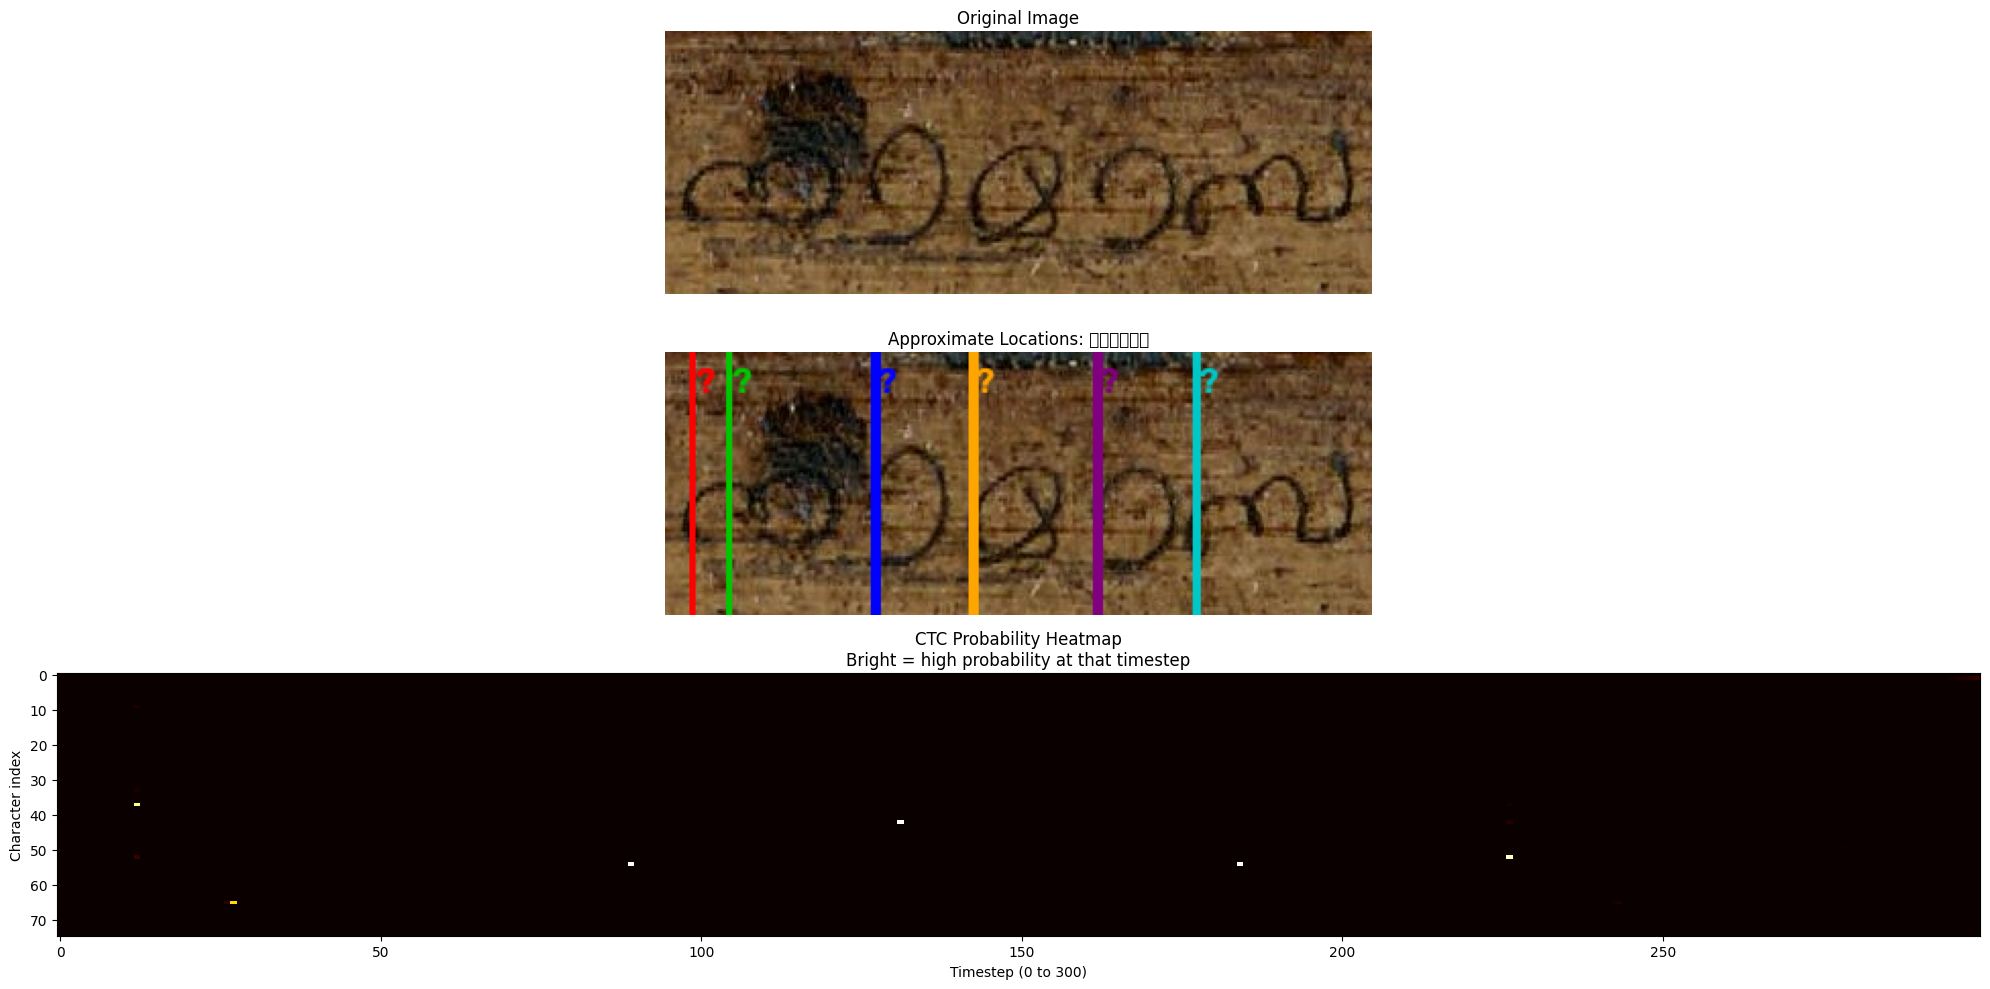

In [13]:
# Run
image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/maI16_00_1-7.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,
    num_to_char = num_to_char
)

Predicted text: നാംപദാനിലാ

Character locations (approximate):
  'ന' → pixels 8 to 8
  'ാ' → pixels 34 to 34
  'ം' → pixels 53 to 54
  'പ' → pixels 66 to 67
  'ദ' → pixels 91 to 92
  'ാ' → pixels 113 to 114
  'ന' → pixels 127 to 128
  'ി' → pixels 152 to 154
  'ല' → pixels 161 to 162
  'ാ' → pixels 182 to 182


/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3368 (\N{MALAYALAM LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3390 (\N{MALAYALAM VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3330 (\N{MALAYALAM SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3370 (\N{MALAYALAM LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3366 (\N{MALAYALAM LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3391 (\N{MALAYALAM VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_lay

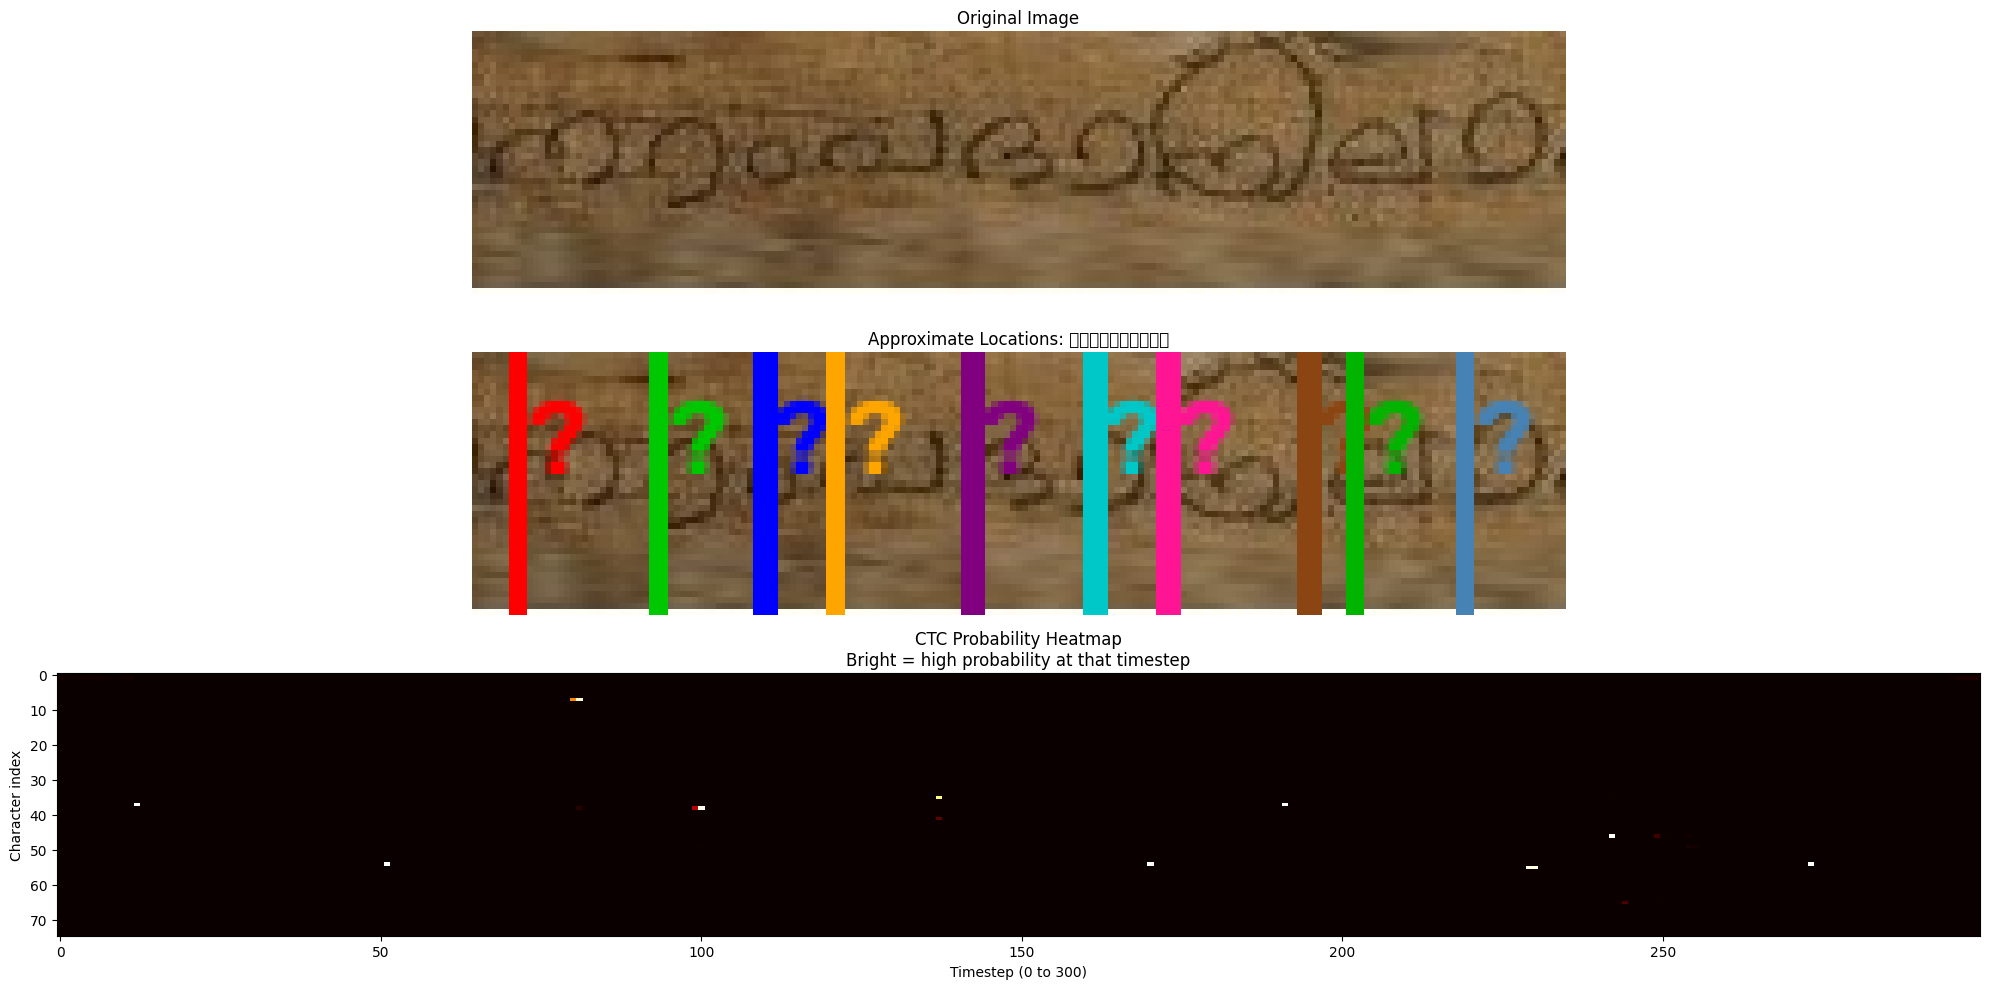

In [15]:

# Run
image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/MaI16_01_9_2.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,
    num_to_char = num_to_char
)

Predicted text: രാമൻ

Character locations (approximate):
  'ര' → pixels 8 to 8
  'ാ' → pixels 62 to 63
  'മ' → pixels 106 to 107
  'ൻ' → pixels 195 to 196


/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3376 (\N{MALAYALAM LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3390 (\N{MALAYALAM VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3374 (\N{MALAYALAM LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/4073716774.py:135: UserWarning: Glyph 3451 (\N{MALAYALAM LETTER CHILLU N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3376 (\N{MALAYALAM LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

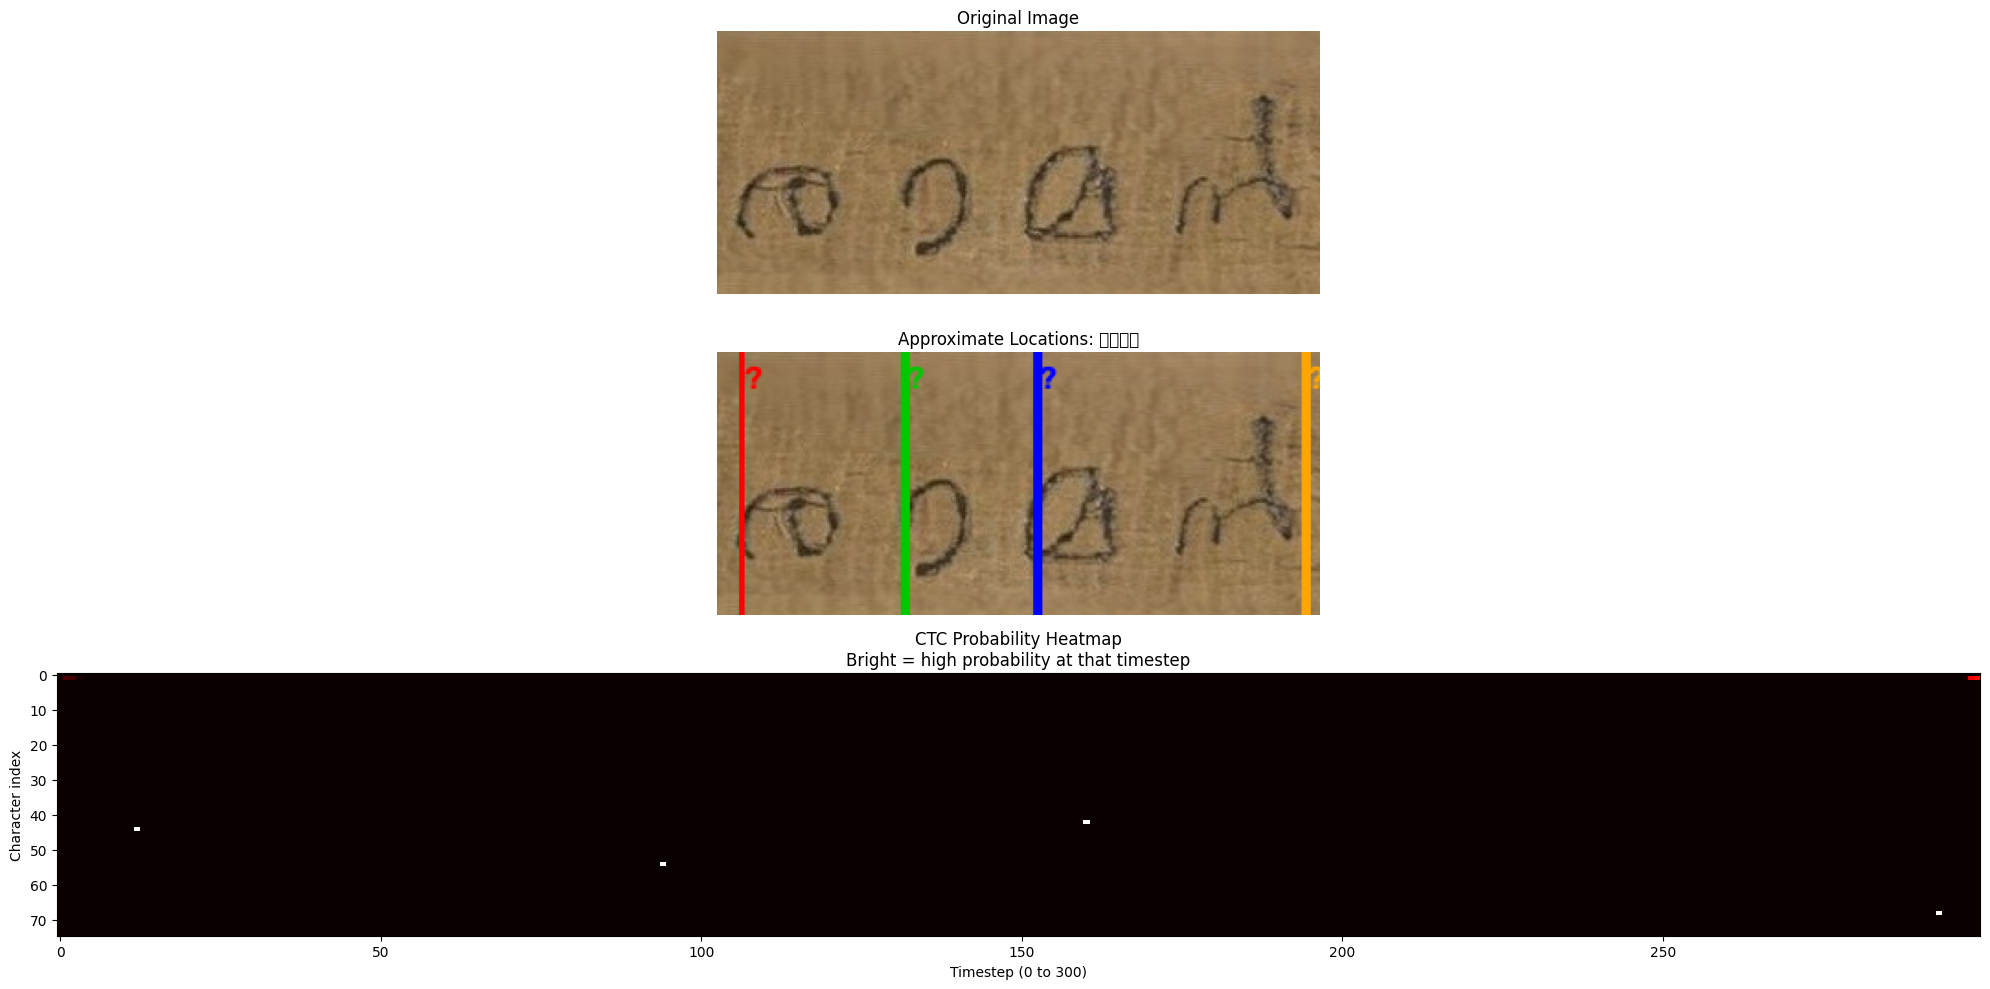

In [16]:
# Run
image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/MaI849_005_8_8.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,
    num_to_char = num_to_char
)

In [23]:
# Complete show_character_locations function

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image, ImageDraw, ImageFont

def show_character_locations(image_path, model,
                              num_to_char,
                              font_path=None,
                              img_w=200, img_h=50):

    # ── Step 1: Load and preprocess image ─────────────────────
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.resize(img, (img_h, img_w))
    img = tf.transpose(img, perm=[1, 0, 2])
    img_input = tf.expand_dims(img, axis=0)  # (1, 200, 50, 3)

    # ── Step 2: Predict ────────────────────────────────────────
    pred        = model.predict(img_input, verbose=0)
    prob_matrix = pred[0]  # (300, 76)

    # ── Step 3: CTC Decode ─────────────────────────────────────
    il          = np.ones(pred.shape[0]) * pred.shape[1]
    decoded_raw = keras.backend.ctc_decode(
        pred, input_length=il, greedy=True
    )[0][0].numpy().flatten()

    predicted_chars = [int(idx) for idx in decoded_raw if idx != -1]

    if len(predicted_chars) == 0:
        print("No characters predicted!")
        return [], prob_matrix

    pred_text = ''.join([
        num_to_char(tf.constant([i])).numpy()[0].decode('utf-8')
        for i in predicted_chars
    ])
    print(f"Predicted: {pred_text}")

    # ── Step 4: Load original image ────────────────────────────
    orig   = cv2.imread(image_path)
    orig   = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    oh, ow = orig.shape[:2]

    # ── Step 5: Equal division of image width ──────────────────
    n_chars    = len(predicted_chars)
    char_width = ow / n_chars

    char_regions = []
    for i, char_idx in enumerate(predicted_chars):
        x1 = int(i * char_width)
        x2 = int((i + 1) * char_width)
        char_regions.append((char_idx, x1, x2))

    print(f"\nCharacter locations:")
    for char_idx, x1, x2 in char_regions:
        ch = num_to_char(
            tf.constant([char_idx])
        ).numpy()[0].decode('utf-8')
        print(f"  '{ch}' → pixels {x1} to {x2}")

    # ── Step 6: Draw boxes on image ────────────────────────────
    colors = [
        (255,0,0),(0,200,0),(0,0,255),(255,165,0),
        (128,0,128),(0,200,200),(255,20,147),
        (139,69,19),(0,180,0),(70,130,180),
    ]

    annotated = orig.copy()
    y1 = oh // 4
    y2 = 3 * oh // 4

    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        # Semi-transparent overlay
        overlay = annotated.copy()
        overlay[y1:y2, x1:x2] = (
            overlay[y1:y2, x1:x2].astype(np.float32) * 0.5
            + np.array(col, np.float32) * 0.5
        ).clip(0,255).astype(np.uint8)
        cv2.addWeighted(overlay, 0.4, annotated, 0.6, 0, annotated)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), col, 2)

    # ── Step 7: Draw Malayalam text using PIL ──────────────────
    annotated_pil = Image.fromarray(annotated)
    draw          = ImageDraw.Draw(annotated_pil)

    try:
        font = ImageFont.truetype(font_path, 22) \
               if font_path else ImageFont.load_default()
    except:
        font = ImageFont.load_default()

    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        ch  = num_to_char(
            tf.constant([char_idx])
        ).numpy()[0].decode('utf-8')
        cx  = x1 + (x2 - x1) // 2 - 5
        draw.text((cx, 5), ch, font=font, fill=col)

    annotated = np.array(annotated_pil)

    # ── Step 8: Plot ───────────────────────────────────────────
    fig, axes = plt.subplots(3, 1, figsize=(18, 10))

    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title(
        f'Approximate Character Locations\n'
        f'Predicted: {pred_text}',
        fontsize=12
    )
    axes[1].axis('off')

    blank_idx = prob_matrix.shape[1] - 1
    axes[2].imshow(
        prob_matrix[:, :blank_idx].T,
        aspect='auto',
        cmap='hot',
        origin='lower'
    )
    axes[2].set_xlabel('Timestep (0 → 300)')
    axes[2].set_ylabel('Character index')
    axes[2].set_title('CTC Probability Heatmap')

    plt.tight_layout()
    plt.show()

    return char_regions, prob_matrix

In [21]:
# Cell - Find Malayalam font first
!apt-get install -y fonts-malayalam fonts-lohit-mlym -q
!fc-cache -fv -q

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

fonts = fm.findSystemFonts()
mal   = [f for f in fonts if any(
    x in f.lower() for x in
    ['malayalam','lohit','anjali','meera','rachana','manjari']
)]
print("Found fonts:")
for f in mal: print(f"  {f}")

MAL_FONT = mal[0] if mal else None
print(f"\nUsing: {MAL_FONT}")

Reading package lists...
Building dependency tree...
Reading state information...
E: Unable to locate package fonts-malayalam
fc-cache: invalid option -- 'q'
usage: fc-cache [-EfrsvVh] [-y SYSROOT] [--error-on-no-fonts] [--force|--really-force] [--sysroot=SYSROOT] [--system-only] [--verbose] [--version] [--help] [dirs]
Build font information caches in [dirs]
(all directories in font configuration by default).

  -E, --error-on-no-fonts  raise an error if no fonts in a directory
  -f, --force              scan directories with apparently valid caches
  -r, --really-force       erase all existing caches, then rescan
  -s, --system-only        scan system-wide directories only
  -y, --sysroot=SYSROOT    prepend SYSROOT to all paths for scanning
  -v, --verbose            display status information while busy
  -V, --version            display font config version and exit
  -h, --help               display this help and exit
Found fonts:

Using: None


Predicted: ന്ാമാസ

Character locations:
  'ന' → pixels 0 to 57
  '്' → pixels 57 to 115
  'ാ' → pixels 115 to 173
  'മ' → pixels 173 to 231
  'ാ' → pixels 231 to 289
  'സ' → pixels 289 to 347


/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Glyph 3368 (\N{MALAYALAM LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Matplotlib currently does not support Malayalam natively.
  plt.tight_layout()
/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Glyph 3405 (\N{MALAYALAM SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Glyph 3390 (\N{MALAYALAM VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Glyph 3374 (\N{MALAYALAM LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4821/2749366906.py:135: UserWarning: Glyph 3384 (\N{MALAYALAM LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3368 (\N{MALAYALAM LETTER NA}) missing from font(s) 

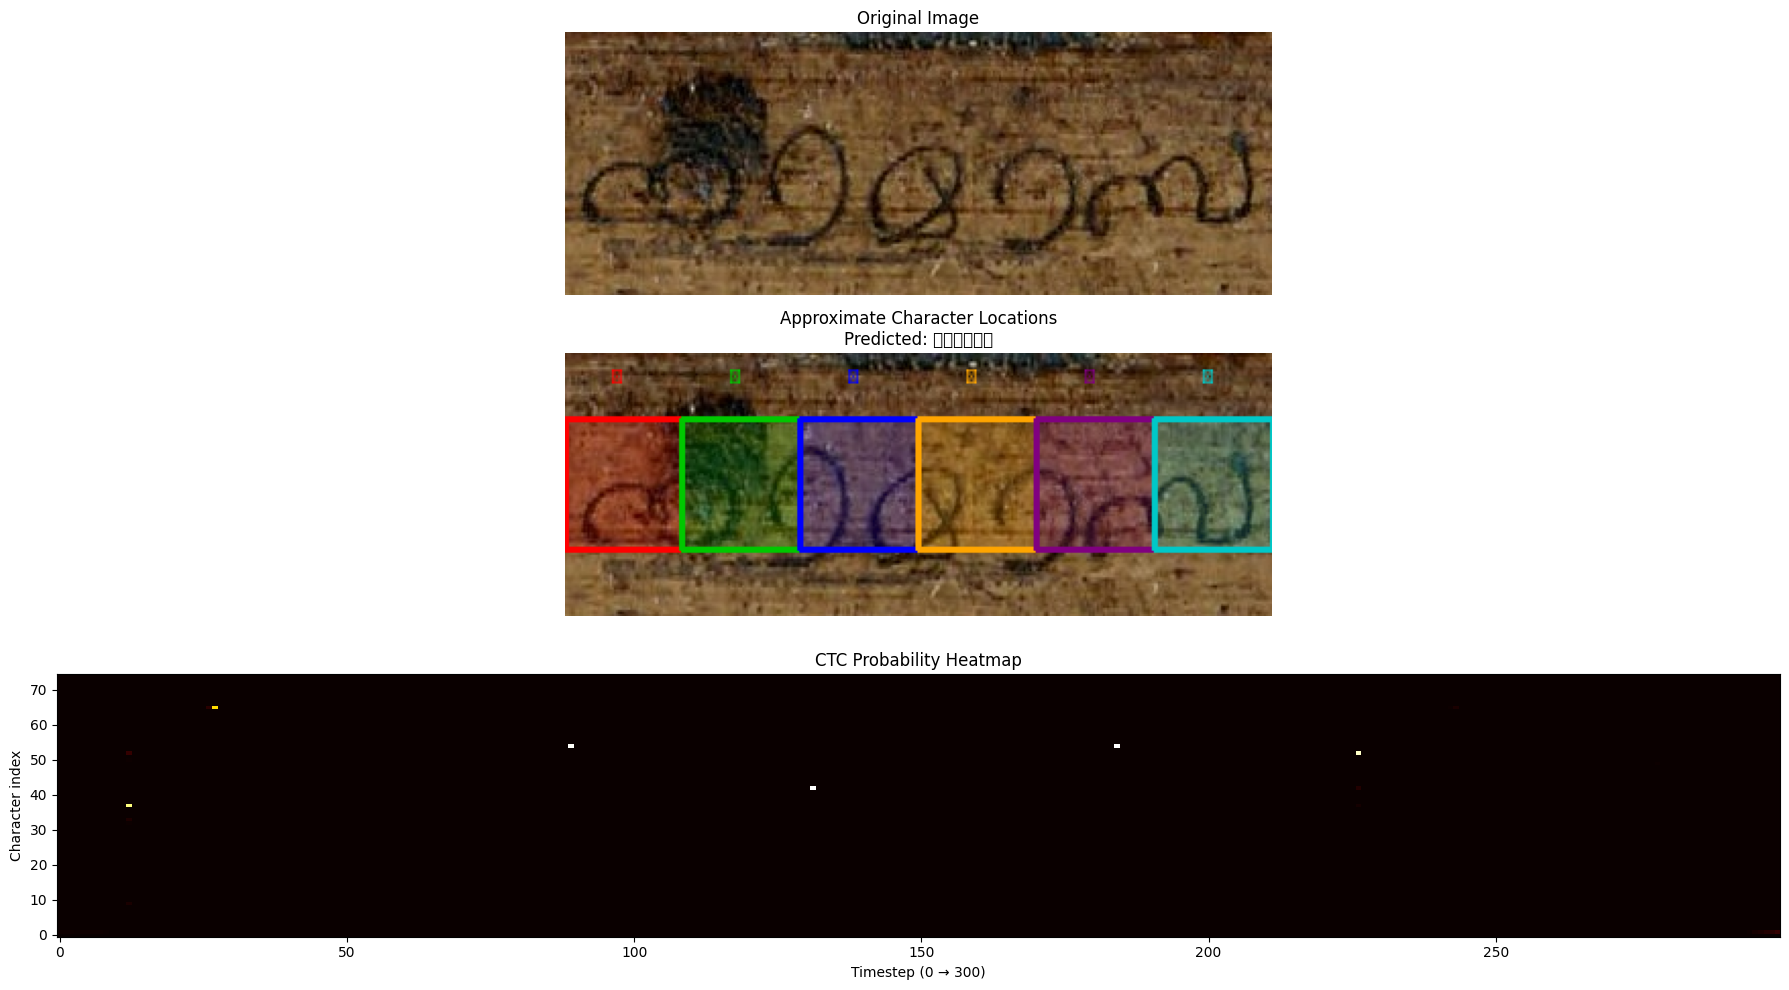

In [24]:
# Cell - Call the function

image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/maI16_00_1-7.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,   # ← your inference model
    num_to_char = num_to_char,       # ← your char mapping
    font_path   = MAL_FONT           # ← Malayalam font
)

In [26]:
# Fix 1: Suppress matplotlib Malayalam warning
# Fix 2: Larger text labels on image
# Fix 3: Show predicted text correctly in terminal

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from tensorflow import keras
from PIL import Image, ImageDraw, ImageFont
import warnings
warnings.filterwarnings('ignore')

def show_character_locations(image_path, model,
                              num_to_char,
                              font_path=None,
                              img_w=200, img_h=50):

    # Step 1: Preprocess
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.resize(img, (img_h, img_w))
    img = tf.transpose(img, perm=[1, 0, 2])
    img_input = tf.expand_dims(img, axis=0)

    # Step 2: Predict
    pred        = model.predict(img_input, verbose=0)
    prob_matrix = pred[0]

    # Step 3: Decode
    il          = np.ones(pred.shape[0]) * pred.shape[1]
    decoded_raw = keras.backend.ctc_decode(
        pred, input_length=il, greedy=True
    )[0][0].numpy().flatten()

    predicted_chars = [int(idx) for idx in decoded_raw if idx != -1]

    if len(predicted_chars) == 0:
        print("No characters predicted!")
        return [], prob_matrix

    pred_text = ''.join([
        num_to_char(tf.constant([i])).numpy()[0].decode('utf-8')
        for i in predicted_chars
    ])

    # Print in terminal (always works!)
    print(f"Predicted text: {pred_text}")
    print(f"Num chars: {len(predicted_chars)}")

    # Step 4: Load original image
    orig   = cv2.imread(image_path)
    orig   = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    oh, ow = orig.shape[:2]

    # Step 5: Equal division
    n_chars    = len(predicted_chars)
    char_width = ow / n_chars

    char_regions = []
    for i, char_idx in enumerate(predicted_chars):
        x1 = int(i * char_width)
        x2 = int((i+1) * char_width)
        char_regions.append((char_idx, x1, x2))
        ch = num_to_char(
            tf.constant([char_idx])
        ).numpy()[0].decode('utf-8')
        print(f"  '{ch}' → pixels {x1} to {x2}")

    # Step 6: Draw boxes
    colors = [
        (255,50,50),(50,200,50),(50,50,255),(255,165,0),
        (180,50,180),(0,200,200),(255,50,150),(160,100,50),
        (50,180,50),(50,150,255),
    ]

    annotated = orig.copy()
    y1 = int(oh * 0.15)
    y2 = int(oh * 0.90)

    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        overlay = annotated.copy()
        overlay[y1:y2, x1:x2] = (
            overlay[y1:y2, x1:x2].astype(np.float32) * 0.45
            + np.array(col, np.float32) * 0.55
        ).clip(0,255).astype(np.uint8)
        cv2.addWeighted(overlay, 0.5, annotated, 0.5, 0, annotated)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), col, 3)

    # Step 7: PIL text — Malayalam characters ON image
    annotated_pil = Image.fromarray(annotated)
    draw          = ImageDraw.Draw(annotated_pil)

    try:
        font_large = ImageFont.truetype(font_path, 28) \
                     if font_path else ImageFont.load_default()
        font_small = ImageFont.truetype(font_path, 16) \
                     if font_path else ImageFont.load_default()
    except:
        font_large = ImageFont.load_default()
        font_small = ImageFont.load_default()

    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        ch  = num_to_char(
            tf.constant([char_idx])
        ).numpy()[0].decode('utf-8')

        # Center text in box
        box_center = x1 + (x2 - x1) // 2

        # White background behind text for visibility
        draw.rectangle(
            [x1+2, 2, x2-2, 35],
            fill=(0, 0, 0, 180)
        )
        draw.text(
            (box_center - 8, 5),
            ch,
            font=font_large,
            fill=col
        )

    annotated = np.array(annotated_pil)

    # Step 8: Plot using PIL for title too (avoids □□□□)
    fig, axes = plt.subplots(3, 1, figsize=(18, 12))

    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    # FIX: Use matplotlib FontProperties for title
    if font_path:
        from matplotlib.font_manager import FontProperties
        fp = FontProperties(fname=font_path)
        axes[1].set_title(
            'Approximate Character Locations',
            fontsize=13
        )
        # Add predicted text as separate text with Malayalam font
        axes[1].text(
            0.5, -0.05,
            f'Predicted: {pred_text}',
            transform=axes[1].transAxes,
            fontsize=14,
            ha='center',
            fontproperties=fp,
            color='black'
        )
    else:
        axes[1].set_title(
            f'Approximate Locations | Predicted: {pred_text}',
            fontsize=13
        )
    axes[1].axis('off')

    blank_idx = prob_matrix.shape[1] - 1
    axes[2].imshow(
        prob_matrix[:, :blank_idx].T,
        aspect='auto',
        cmap='hot',
        origin='lower'
    )
    axes[2].set_xlabel('Timestep (0 → 300)', fontsize=11)
    axes[2].set_ylabel('Character index (0 → vocab)', fontsize=11)
    axes[2].set_title(
        'CTC Probability Heatmap\n'
        'Bright spots = model confident about that character at that timestep',
        fontsize=11
    )

    plt.tight_layout()
    plt.savefig('char_locations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✅ Saved: char_locations.png")

    return char_regions, prob_matrix

Predicted text: ന്ാമാസ
Num chars: 6
  'ന' → pixels 0 to 57
  '്' → pixels 57 to 115
  'ാ' → pixels 115 to 173
  'മ' → pixels 173 to 231
  'ാ' → pixels 231 to 289
  'സ' → pixels 289 to 347


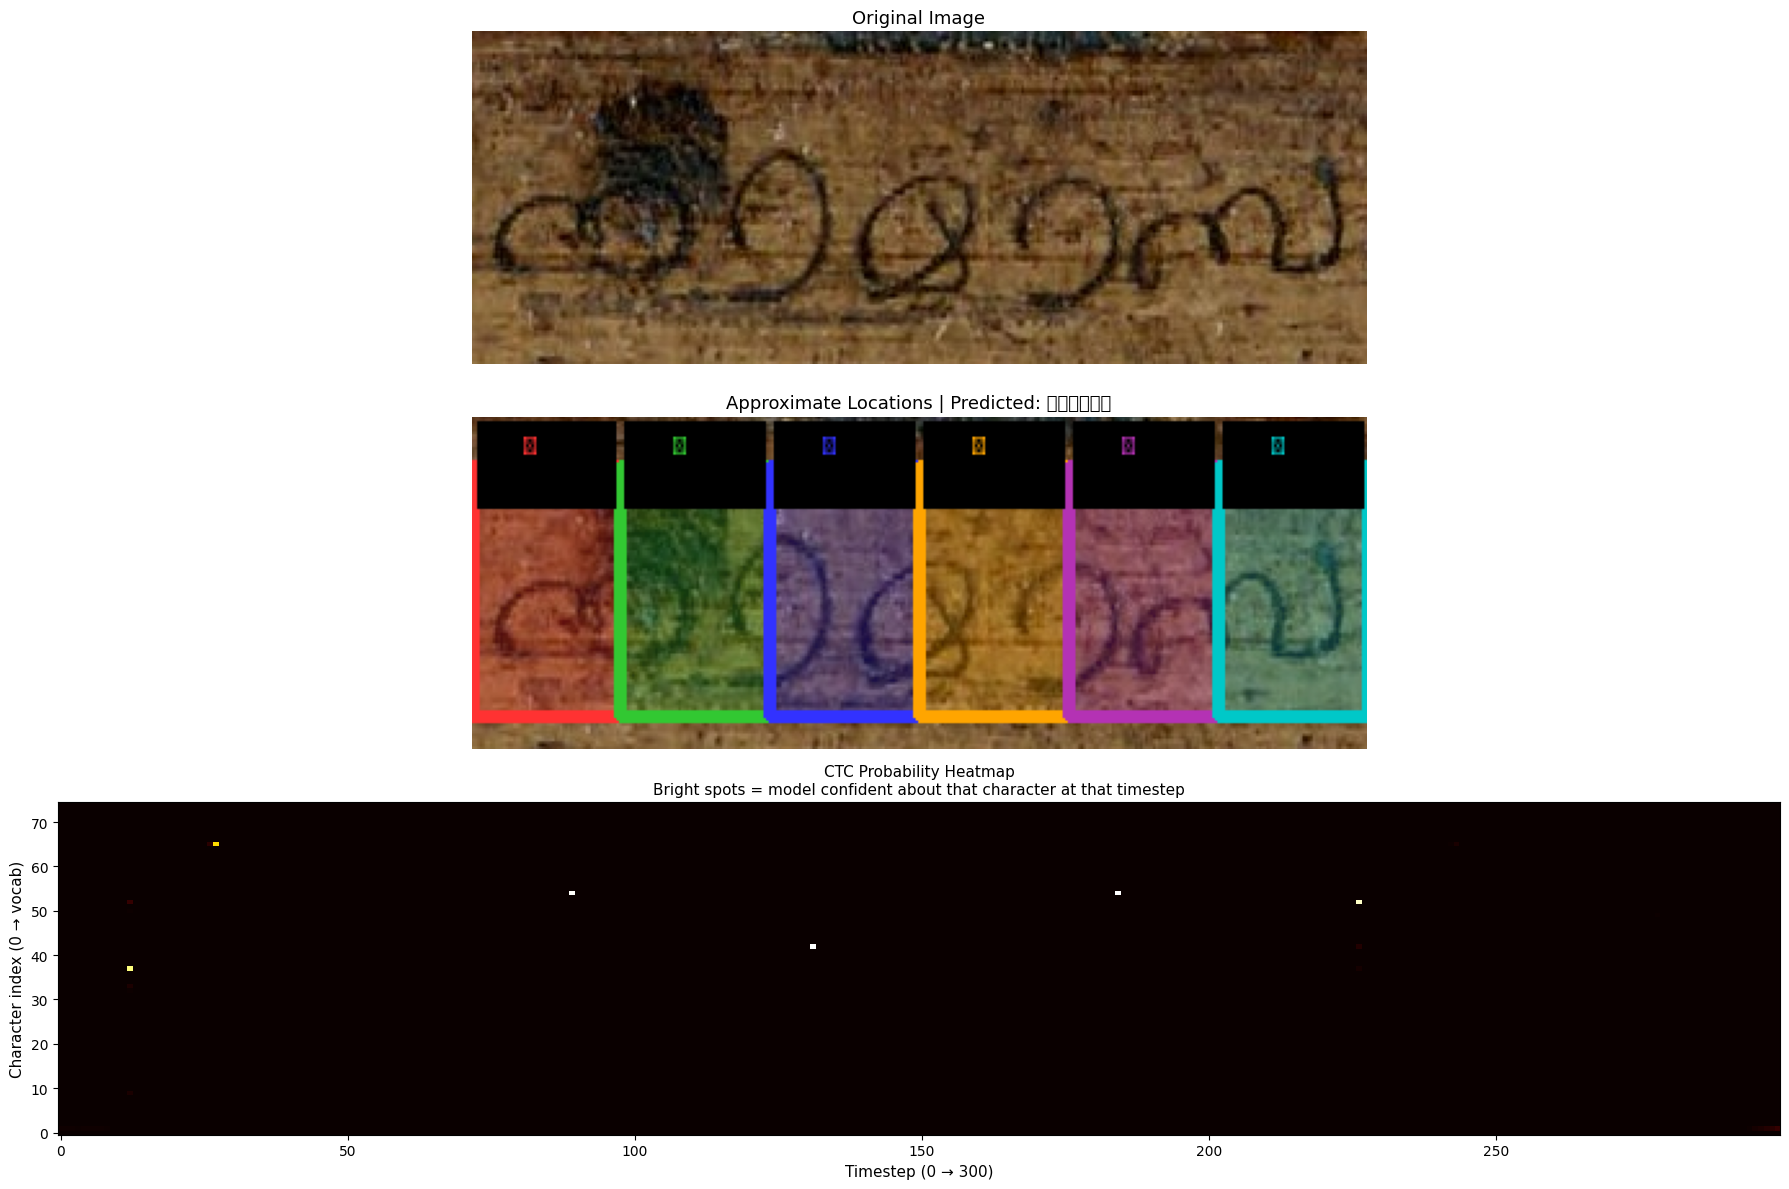


✅ Saved: char_locations.png


In [27]:
# Cell - Call the function

image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/maI16_00_1-7.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,   # ← your inference model
    num_to_char = num_to_char,       # ← your char mapping
    font_path   = MAL_FONT           # ← Malayalam font
)

In [28]:
def show_character_locations(image_path, model,
                              num_to_char,
                              font_path=None,
                              img_w=200, img_h=50):

    # Step 1: Preprocess
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, dtype=tf.float32)
    img = tf.image.resize(img, (img_h, img_w))
    img = tf.transpose(img, perm=[1, 0, 2])
    img_input = tf.expand_dims(img, axis=0)

    # Step 2: Predict
    pred        = model.predict(img_input, verbose=0)
    prob_matrix = pred[0]

    # Step 3: Decode
    il          = np.ones(pred.shape[0]) * pred.shape[1]
    decoded_raw = keras.backend.ctc_decode(
        pred, input_length=il, greedy=True
    )[0][0].numpy().flatten()

    predicted_chars = [int(idx) for idx in decoded_raw if idx != -1]
    if len(predicted_chars) == 0:
        print("No characters predicted!")
        return [], prob_matrix

    pred_text = ''.join([
        num_to_char(tf.constant([i])).numpy()[0].decode('utf-8')
        for i in predicted_chars
    ])
    print(f"Predicted: {pred_text}")

    # Step 4: Load image
    orig   = cv2.imread(image_path)
    orig   = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    oh, ow = orig.shape[:2]

    # Step 5: Equal division
    n_chars    = len(predicted_chars)
    char_width = ow / n_chars

    char_regions = []
    for i, char_idx in enumerate(predicted_chars):
        x1 = int(i * char_width)
        x2 = int((i+1) * char_width)
        char_regions.append((char_idx, x1, x2))
        ch = num_to_char(tf.constant([char_idx])).numpy()[0].decode('utf-8')
        print(f"  '{ch}' → pixels {x1} to {x2}")

    colors = [
        (255,50,50),(50,200,50),(50,50,255),(255,165,0),
        (180,50,180),(0,200,200),(255,50,150),(160,100,50),
        (50,180,50),(50,150,255),
    ]

    y1 = int(oh * 0.15)
    y2 = int(oh * 0.90)

    # FIX: Create overlay ONCE, draw ALL boxes on it, blend ONCE
    overlay  = orig.copy()
    annotated = orig.copy()

    # Draw ALL colored fills on overlay first
    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        overlay[y1:y2, x1:x2] = col   # solid color fill

    # Blend overlay with original ONCE
    cv2.addWeighted(overlay, 0.35, annotated, 0.65, 0, annotated)

    # Draw borders AFTER blending (solid, no transparency needed)
    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), col, 3)

    # Step 7: PIL text
    annotated_pil = Image.fromarray(annotated)
    draw          = ImageDraw.Draw(annotated_pil)

    try:
        font_large = ImageFont.truetype(font_path, 28) \
                     if font_path else ImageFont.load_default()
    except:
        font_large = ImageFont.load_default()

    for i, (char_idx, x1, x2) in enumerate(char_regions):
        col = colors[i % len(colors)]
        ch  = num_to_char(
            tf.constant([char_idx])
        ).numpy()[0].decode('utf-8')
        box_center = x1 + (x2 - x1) // 2 - 8
        # Black background behind label
        draw.rectangle([x1+2, 2, x2-2, 36], fill=(0,0,0))
        draw.text((box_center, 4), ch, font=font_large, fill=col)

    annotated = np.array(annotated_pil)

    # Step 8: Plot
    fig, axes = plt.subplots(3, 1, figsize=(18, 12))

    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(annotated)
    axes[1].set_title('Approximate Character Locations', fontsize=13)
    if font_path:
        from matplotlib.font_manager import FontProperties
        fp = FontProperties(fname=font_path)
        axes[1].text(
            0.5, -0.05,
            f'Predicted: {pred_text}',
            transform=axes[1].transAxes,
            fontsize=14, ha='center',
            fontproperties=fp
        )
    axes[1].axis('off')

    blank_idx = prob_matrix.shape[1] - 1
    axes[2].imshow(
        prob_matrix[:, :blank_idx].T,
        aspect='auto', cmap='hot', origin='lower'
    )
    axes[2].set_xlabel('Timestep (0 → 300)')
    axes[2].set_ylabel('Character index')
    axes[2].set_title('CTC Probability Heatmap')

    plt.tight_layout()
    plt.savefig('char_locations.png', dpi=150, bbox_inches='tight')
    plt.show()

    return char_regions, prob_matrix

Predicted: ന്ാമാസ
  'ന' → pixels 0 to 57
  '്' → pixels 57 to 115
  'ാ' → pixels 115 to 173
  'മ' → pixels 173 to 231
  'ാ' → pixels 231 to 289
  'സ' → pixels 289 to 347


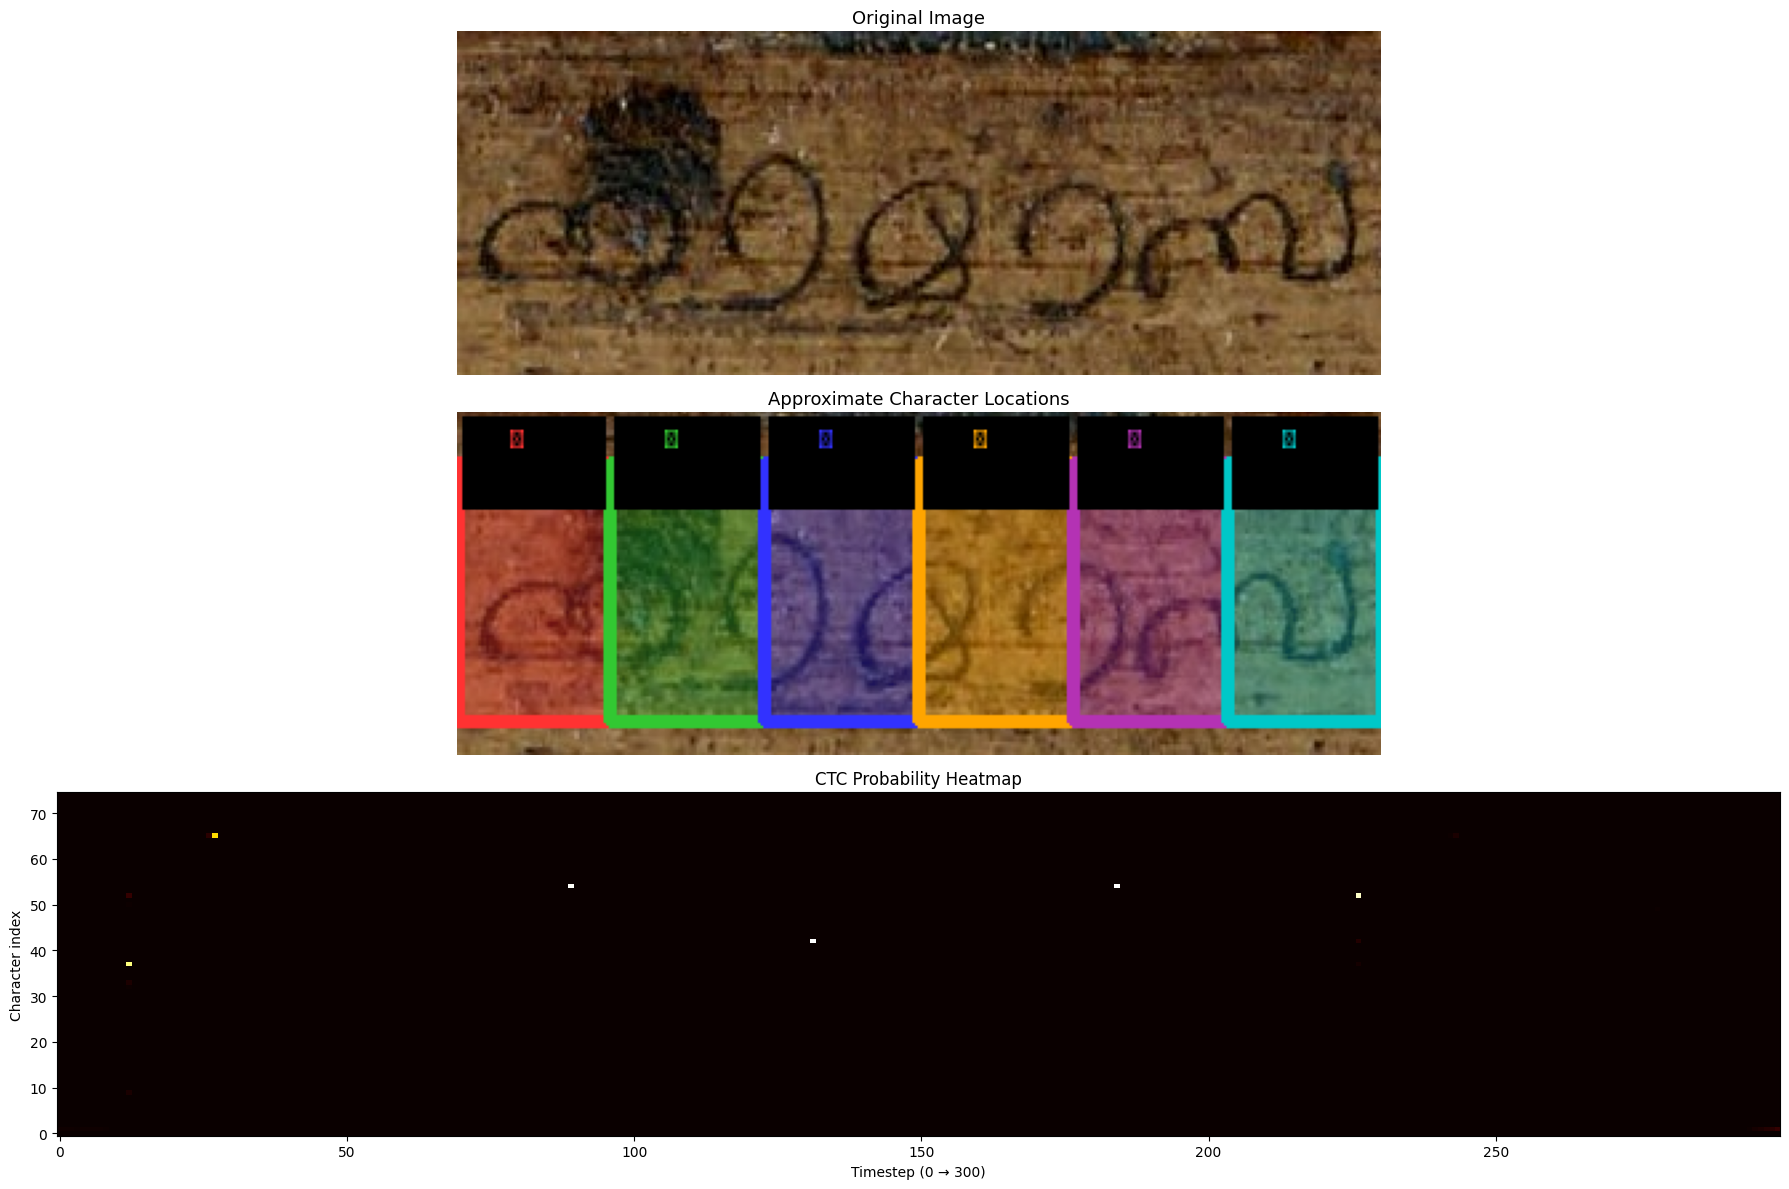

In [29]:
# Cell - Call the function

image_path = '/content/drive/MyDrive/demo-linesegdataset/demo-linesegdataset/recogniton/split_output/test/images/maI16_00_1-7.jpg'

char_regions, prob_matrix = show_character_locations(
    image_path  = image_path,
    model       = model,   # ← your inference model
    num_to_char = num_to_char,       # ← your char mapping
    font_path   = MAL_FONT           # ← Malayalam font
)